# Exploratory Data Analysis

## Grid Peak-Load Prediction and Renewable Reliability Window Analysis

### ENTSO-E Electricity System Time-Series Dataset

This notebook presents an exploratory data analysis of historical electricity-system data obtained from the ENTSO-E Transparency Platform.

The analysis investigates electricity demand patterns, renewable-generation variability, renewable coverage, renewable-demand mismatch, peak-load conditions, and potential renewable reliability windows.

The findings from this analysis provide the basis for feature engineering, reliability-window identification, and subsequent peak-load prediction.

### Main Objectives

- Examine the structure and quality of the ENTSO-E dataset.
- Analyze electricity demand patterns across time.
- Investigate solar, wind, and hydro generation variability.
- Quantify renewable coverage of electricity demand.
- Analyze the renewable-demand gap.
- Identify peak-demand observations.
- Examine whether peak demand coincides with low renewable availability.
- Identify candidate renewable reliability windows.
- Identify variables and relationships relevant to subsequent machine-learning analysis.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy import stats

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

# Visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the ENTSO-E Dataset


In [2]:
from pathlib import Path

DATA_PATH = Path("../data/Raw/Dataset.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (105216, 17)


In [3]:
df.head()

,Timestamp_UTC,Hydro Run-of-River [MW],Hydro water reservoir [MW],Wind offshore [MW],Wind onshore [MW],Solar [MW],Load [MW],renewable_total_MW,renewable_coverage_pct,renewable_gap_MW,hour,day_of_week,day_of_year,month,is_weekend,peak_flag,risk_score
0,31-12-2022 23:00,1205.50,73.10,2737.40,28841.80,2.30,38691.80,32860.10,84.93,5831.70,23,5,365,12,1,0,0.00
1,31-12-2022 23:15,1203.30,66.00,2973.80,28895.30,1.70,38374.20,33140.10,86.36,5234.10,23,5,365,12,1,0,0.00
2,31-12-2022 23:30,1203.40,65.40,3267.60,29305.80,1.40,38248.00,33843.60,88.48,4404.40,23,5,365,12,1,0,0.00
3,31-12-2022 23:45,1201.30,83.60,3257.60,28745.70,1.70,38070.20,33289.90,87.44,4780.30,23,5,365,12,1,0,0.00
4,01-01-2023 00:00,1201.50,57.30,3142.20,29468.90,1.50,37733.40,33871.40,89.77,3862.00,0,6,1,1,1,0,0.00


In [4]:
df.tail()

,Timestamp_UTC,Hydro Run-of-River [MW],Hydro water reservoir [MW],Wind offshore [MW],Wind onshore [MW],Solar [MW],Load [MW],renewable_total_MW,renewable_coverage_pct,renewable_gap_MW,hour,day_of_week,day_of_year,month,is_weekend,peak_flag,risk_score
105211,31-12-2025 21:45,975.90,59.90,3615.30,30560.90,14.30,48369.30,35226.30,72.83,13143.00,21,2,365,12,0,0,0.00
105212,31-12-2025 22:00,964.70,30.80,2899.60,30541.40,17.20,47816.10,34453.70,72.05,13362.40,22,2,365,12,0,0,0.00
105213,31-12-2025 22:15,980.60,30.20,2942.20,30971.40,11.10,47620.60,34935.50,73.36,12685.10,22,2,365,12,0,0,0.00
105214,31-12-2025 22:30,971.60,13.20,3071.80,31700.80,11.00,47274.50,35768.40,75.66,11506.10,22,2,365,12,0,0,0.00
105215,31-12-2025 22:45,971.00,13.40,3099.60,32243.30,10.90,47027.30,36338.20,77.27,10689.10,22,2,365,12,0,0,0.00


## 3. Dataset Structure

In [5]:
print("Number of observations:", df.shape[0])
print("Number of variables:", df.shape[1])

print("\nVariables in the dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Number of observations: 105216
Number of variables: 17

Variables in the dataset:

1. Timestamp_UTC
2. Hydro Run-of-River [MW]
3. Hydro water reservoir [MW]
4. Wind offshore [MW]
5. Wind onshore [MW]
6. Solar [MW]
7. Load [MW]
8. renewable_total_MW
9. renewable_coverage_pct
10. renewable_gap_MW
11. hour
12. day_of_week
13. day_of_year
14. month
15. is_weekend
16. peak_flag
17. risk_score


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 105216 entries, 0 to 105215
Data columns (total 17 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Timestamp_UTC               105216 non-null  str    
 1   Hydro Run-of-River [MW]     105216 non-null  float64
 2   Hydro water reservoir [MW]  105216 non-null  float64
 3   Wind offshore [MW]          105216 non-null  float64
 4   Wind onshore [MW]           105216 non-null  float64
 5   Solar [MW]                  105216 non-null  float64
 6   Load [MW]                   105216 non-null  float64
 7   renewable_total_MW          105216 non-null  float64
 8   renewable_coverage_pct      105216 non-null  float64
 9   renewable_gap_MW            105216 non-null  float64
 10  hour                        105216 non-null  int64  
 11  day_of_week                 105216 non-null  int64  
 12  day_of_year                 105216 non-null  int64  
 13  month                    

## 4. Dataset Variable Groups

The variables are grouped into three main categories:

1. **Actual electricity-system variables** — electricity load and renewable-generation measurements.
2. **Temporal variables** — hour, day of week, day of year, month, and weekend indicator.
3. **Derived analytical variables** — renewable total, renewable coverage, renewable-demand gap, peak flag, and risk score.


In [7]:
actual_columns = [
    "Hydro Run-of-River [MW]",
    "Hydro water reservoir [MW]",
    "Wind offshore [MW]",
    "Wind onshore [MW]",
    "Solar [MW]",
    "Load [MW]"
]

temporal_columns = [
    "hour",
    "day_of_week",
    "day_of_year",
    "month",
    "is_weekend"
]

derived_columns = [
    "renewable_total_MW",
    "renewable_coverage_pct",
    "renewable_gap_MW",
    "peak_flag",
    "risk_score"
]

print("Actual variables:", len(actual_columns))
print("Temporal variables:", len(temporal_columns))
print("Derived variables:", len(derived_columns))


Actual variables: 6
Temporal variables: 5
Derived variables: 5


## 5. Timestamp Processing and Validation

The timestamp is the primary temporal index of the dataset. Since the project performs high-resolution time-series analysis, timestamp continuity must be verified before further analysis.

The dataset is expected to contain observations at 15-minute intervals.

In [8]:
df["Timestamp_UTC"] = pd.to_datetime(
    df["Timestamp_UTC"],
    format="%d-%m-%Y %H:%M",
    utc=True
)

print("Timestamp conversion completed.")
print("Start:", df["Timestamp_UTC"].min())
print("End:", df["Timestamp_UTC"].max())

Timestamp conversion completed.
Start: 2022-12-31 23:00:00+00:00
End: 2025-12-31 22:45:00+00:00


In [9]:
is_sorted = df["Timestamp_UTC"].is_monotonic_increasing

print("Timestamps sorted chronologically:", is_sorted)

Timestamps sorted chronologically: True


In [10]:

time_difference = (
    df["Timestamp_UTC"]
    .diff()
    .dropna()
)


print("Most common time intervals between observations:")
print(time_difference.value_counts().head())

expected_interval = pd.Timedelta(minutes=15)

all_intervals_correct = (
    time_difference == expected_interval
).all()

print("\nExpected interval:", expected_interval)
print(
    "All intervals equal 15 minutes:",
    all_intervals_correct
)


incorrect_intervals = (
    time_difference != expected_interval
).sum()

print(
    "Number of incorrect time intervals:",
    incorrect_intervals
)

Most common time intervals between observations:
Timestamp_UTC
0 days 00:15:00    105215
Name: count, dtype: int64

Expected interval: 0 days 00:15:00
All intervals equal 15 minutes: True
Number of incorrect time intervals: 0


## 6. Data Quality Analysis

Data quality is evaluated by checking missing values, duplicate observations, timestamp continuity, and invalid numerical values.

These checks are important because missing or inconsistent observations could affect peak-load identification, renewable coverage calculations, and machine-learning evaluation.

In [11]:
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

if missing_values.sum() == 0:
    print("No missing values detected.")
else:
    display(missing_values[missing_values > 0])

Total missing values: 0
No missing values detected.


In [12]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [13]:
duplicate_timestamps = df["Timestamp_UTC"].duplicated().sum()

print("Duplicate timestamps:", duplicate_timestamps)

Duplicate timestamps: 0


In [14]:
physical_columns = actual_columns

negative_counts = (
    df[physical_columns] < 0
).sum()

negative_counts

Hydro Run-of-River [MW]       0
Hydro water reservoir [MW]    0
Wind offshore [MW]            0
Wind onshore [MW]             0
Solar [MW]                    0
Load [MW]                     0
dtype: int64

### Data Quality Summary

The dataset contains 105,216 observations recorded at 15-minute intervals over approximately three years. The timestamp sequence is continuous, with no duplicate timestamps. No missing values or duplicate rows are present in the dataset.

These characteristics make the dataset suitable for high-resolution temporal analysis of electricity demand and renewable-generation behavior.

## 7. Descriptive Statistics


In [15]:
df[actual_columns].describe()

,Hydro Run-of-River [MW],Hydro water reservoir [MW],Wind offshore [MW],Wind onshore [MW],Solar [MW],Load [MW]
count,105216.00,105216.00,105216.00,105216.00,105216.00,105216.00
mean,1596.77,180.69,2865.79,12862.50,7317.37,52832.35
std,284.30,183.86,1938.86,9954.90,11243.19,9152.91
min,922.90,0.00,0.00,42.40,1.30,27932.90
25%,1366.00,49.90,1125.70,4916.90,6.10,45316.67
50%,1622.60,115.30,2612.80,10211.40,131.75,52877.80
75%,1824.50,245.10,4472.40,18643.10,11708.30,59737.12
max,2355.90,1093.10,8367.60,48606.70,52836.50,75965.70


In [16]:
load_statistics = df["Load [MW]"].describe(
    percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

load_statistics

count   105216.00
mean     52832.35
std       9152.91
min      27932.90
25%      45316.67
50%      52877.80
75%      59737.12
90%      65389.20
95%      68180.27
99%      71536.85
max      75965.70
Name: Load [MW], dtype: float64

## 8. Electricity Load Analysis

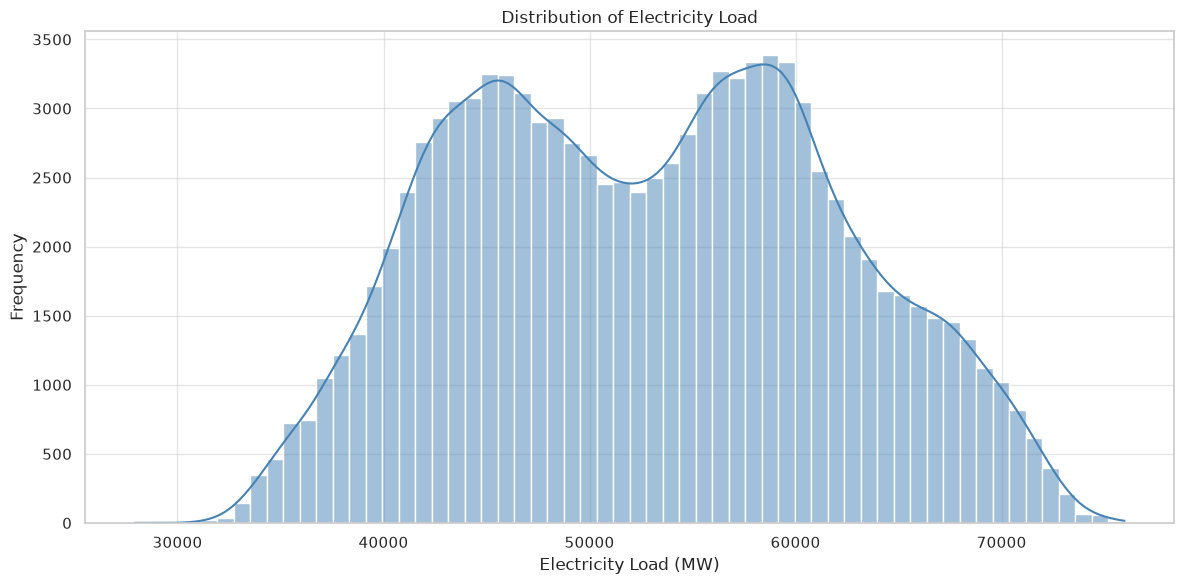

In [17]:
plt.figure(figsize=(12, 6))

sns.histplot(
    df["Load [MW]"],
    bins=60,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Electricity Load")
plt.xlabel("Electricity Load (MW)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

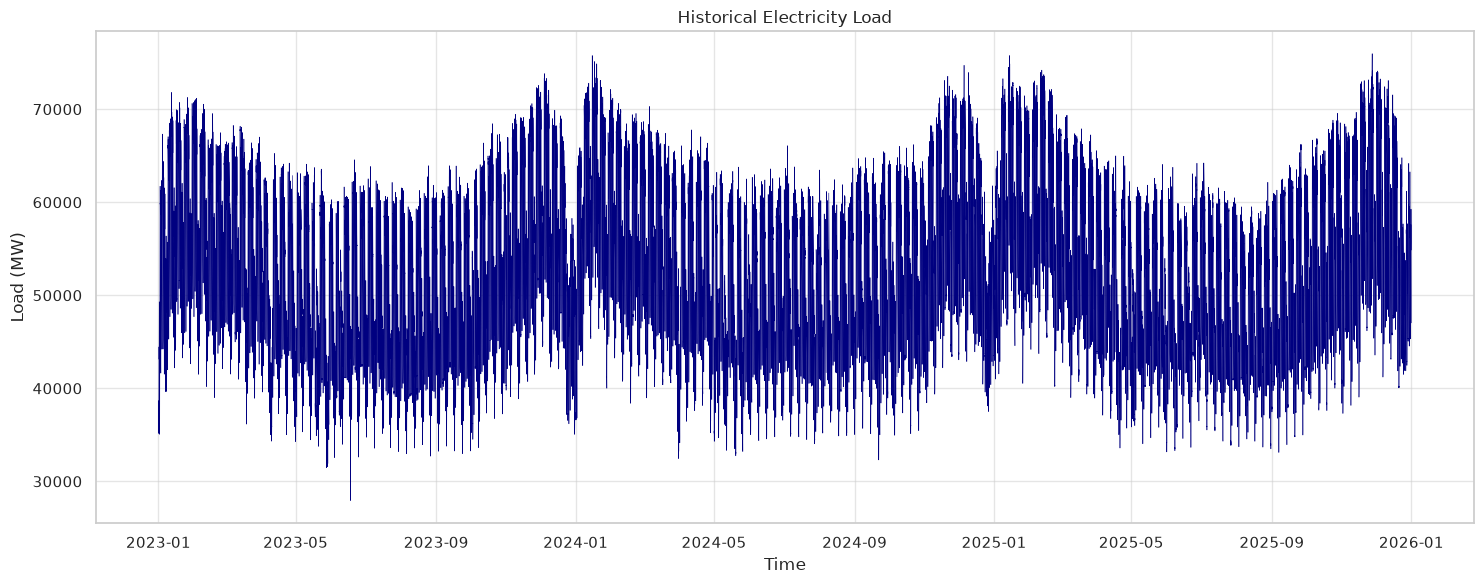

In [18]:
plt.figure(figsize=(15, 6))

plt.plot(
    df["Timestamp_UTC"],
    df["Load [MW]"],
    linewidth=0.4,
    color="navy"
)

plt.title("Historical Electricity Load")
plt.xlabel("Time")
plt.ylabel("Load (MW)")

plt.tight_layout()
plt.show()

## 9. Temporal Load Analysis

In [19]:
hourly_load = (
    df.groupby("hour")["Load [MW]"]
    .agg(["mean", "min", "max"])
)

hourly_load

,mean,min,max
hour,,,
0,42577.42,31990.70,56732.80
1,42232.82,31569.50,55670.70
2,42709.12,27932.90,55918.20
3,44438.50,31471.00,56528.20
4,48309.19,31532.40,61796.70
5,52730.52,33842.50,69766.60
6,56232.61,35834.40,74724.00
7,58141.87,36244.50,75543.40
8,59070.76,38084.00,75529.40


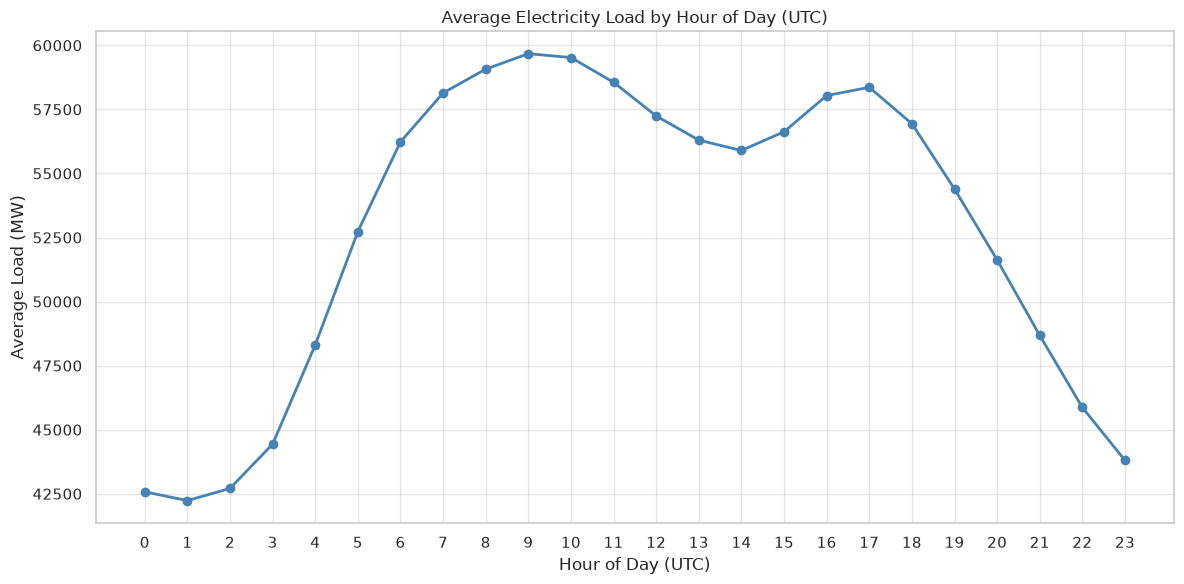

In [20]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_load.index,
    hourly_load["mean"],
    marker="o",
    linewidth=2,
    color="steelblue"
)

plt.title("Average Electricity Load by Hour of Day (UTC)")
plt.xlabel("Hour of Day (UTC)")
plt.ylabel("Average Load (MW)")
plt.xticks(range(24))

plt.tight_layout()
plt.show()

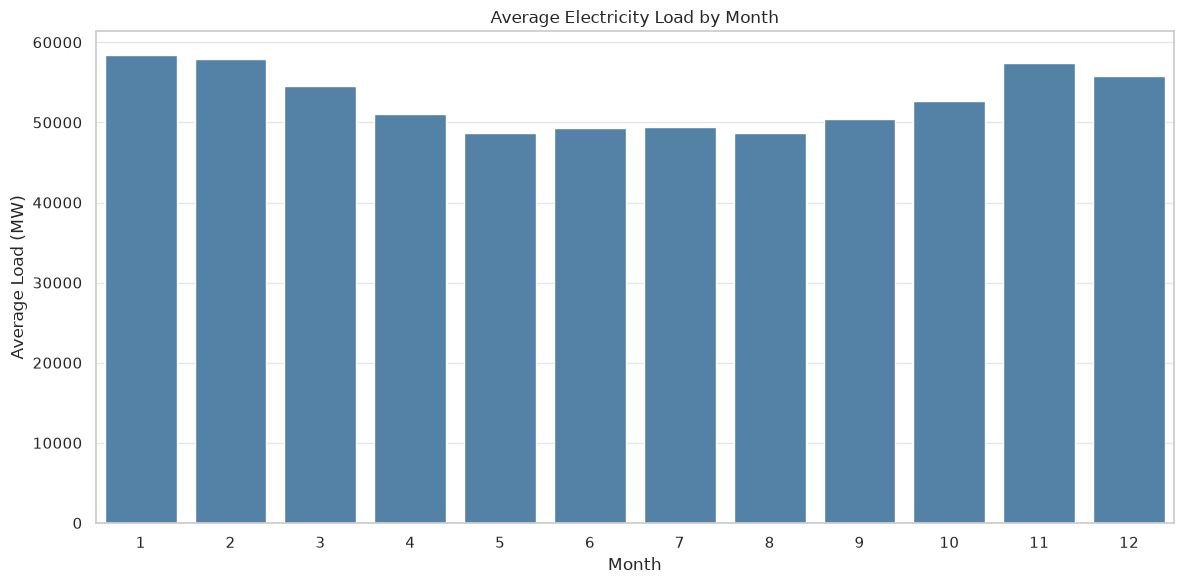

In [21]:
monthly_load = (
    df.groupby("month")["Load [MW]"]
    .mean()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=monthly_load.index,
    y=monthly_load.values,
    color="steelblue"
)

plt.title("Average Electricity Load by Month")
plt.xlabel("Month")
plt.ylabel("Average Load (MW)")

plt.tight_layout()
plt.show()

,Day Type,Average Load (MW)
0,Weekday,55470.03
1,Weekend,46235.19


Weekday − Weekend difference: 9,234.84 MW


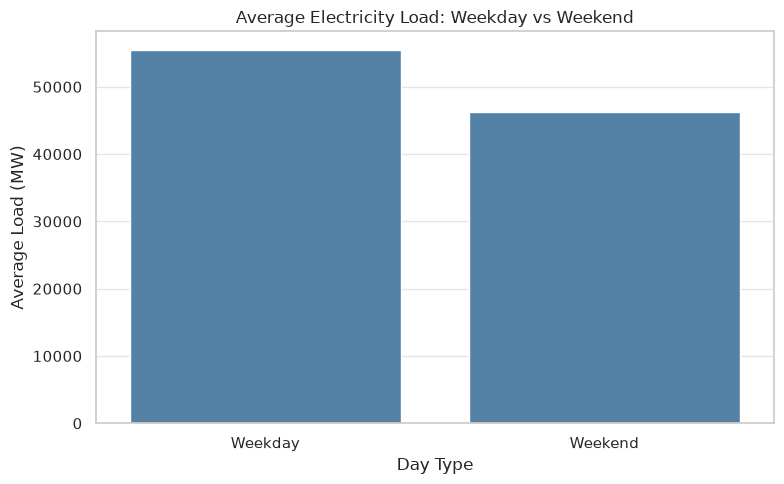

In [22]:

weekend_comparison = (
    df.groupby("is_weekend")["Load [MW]"]
    .mean()
)


comparison = pd.DataFrame({
    "Day Type": ["Weekday", "Weekend"],
    "Average Load (MW)": [
        weekend_comparison.iloc[0],
        weekend_comparison.iloc[1]
    ]
})


display(comparison)

difference = (
    weekend_comparison.iloc[0]
    - weekend_comparison.iloc[1]
)

print(f"Weekday − Weekend difference: {difference:,.2f} MW")


plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="Day Type",
    y="Average Load (MW)",
    color="steelblue"
)

plt.title("Average Electricity Load: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Load (MW)")

plt.tight_layout()
plt.show()

## 10. Renewable Generation Analysis

In [23]:
renewable_columns = [
    "Solar [MW]",
    "Wind onshore [MW]",
    "Wind offshore [MW]",
    "Hydro Run-of-River [MW]",
    "Hydro water reservoir [MW]"
]

renewable_statistics = df[renewable_columns].describe().T

renewable_statistics

,count,mean,std,min,25%,50%,75%,max
Solar [MW],105216.00,7317.37,11243.19,1.30,6.10,131.75,11708.30,52836.50
Wind onshore [MW],105216.00,12862.50,9954.90,42.40,4916.90,10211.40,18643.10,48606.70
Wind offshore [MW],105216.00,2865.79,1938.86,0.00,1125.70,2612.80,4472.40,8367.60
Hydro Run-of-River [MW],105216.00,1596.77,284.30,922.90,1366.00,1622.60,1824.50,2355.90
Hydro water reservoir [MW],105216.00,180.69,183.86,0.00,49.90,115.30,245.10,1093.10


### Average Renewable Generation by Source

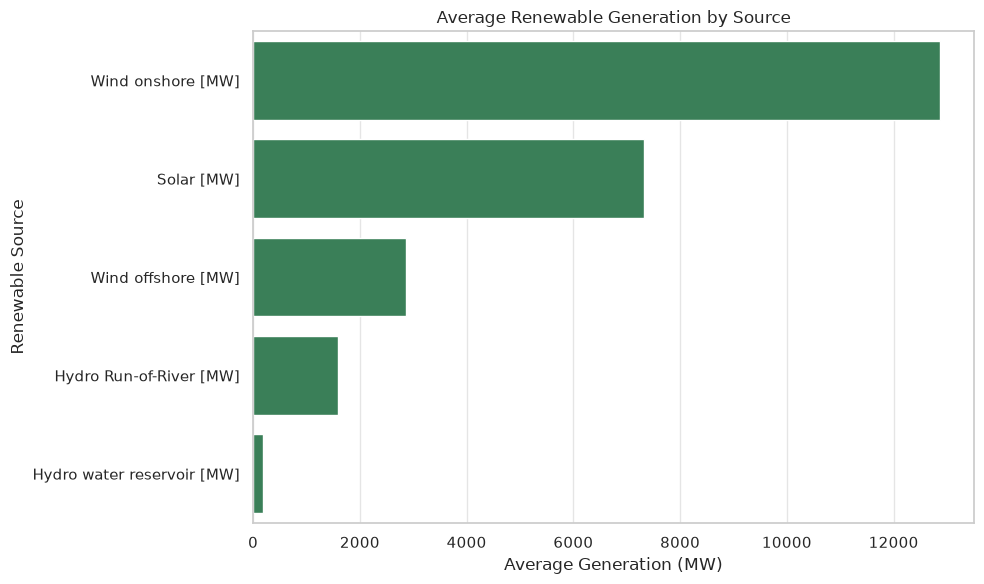

In [24]:
renewable_means = (
    df[renewable_columns]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=renewable_means.values,
    y=renewable_means.index,
    color="seagreen"
)

plt.title("Average Renewable Generation by Source")
plt.xlabel("Average Generation (MW)")
plt.ylabel("Renewable Source")

plt.tight_layout()
plt.show()

### Renewable Generation Over Time

This analysis examines the temporal variation of solar, onshore wind, offshore wind, and hydro generation throughout the study period. The time-series visualization helps identify fluctuations in renewable availability and provides an initial understanding of the variability that may contribute to renewable-demand mismatches during periods of high electricity demand.

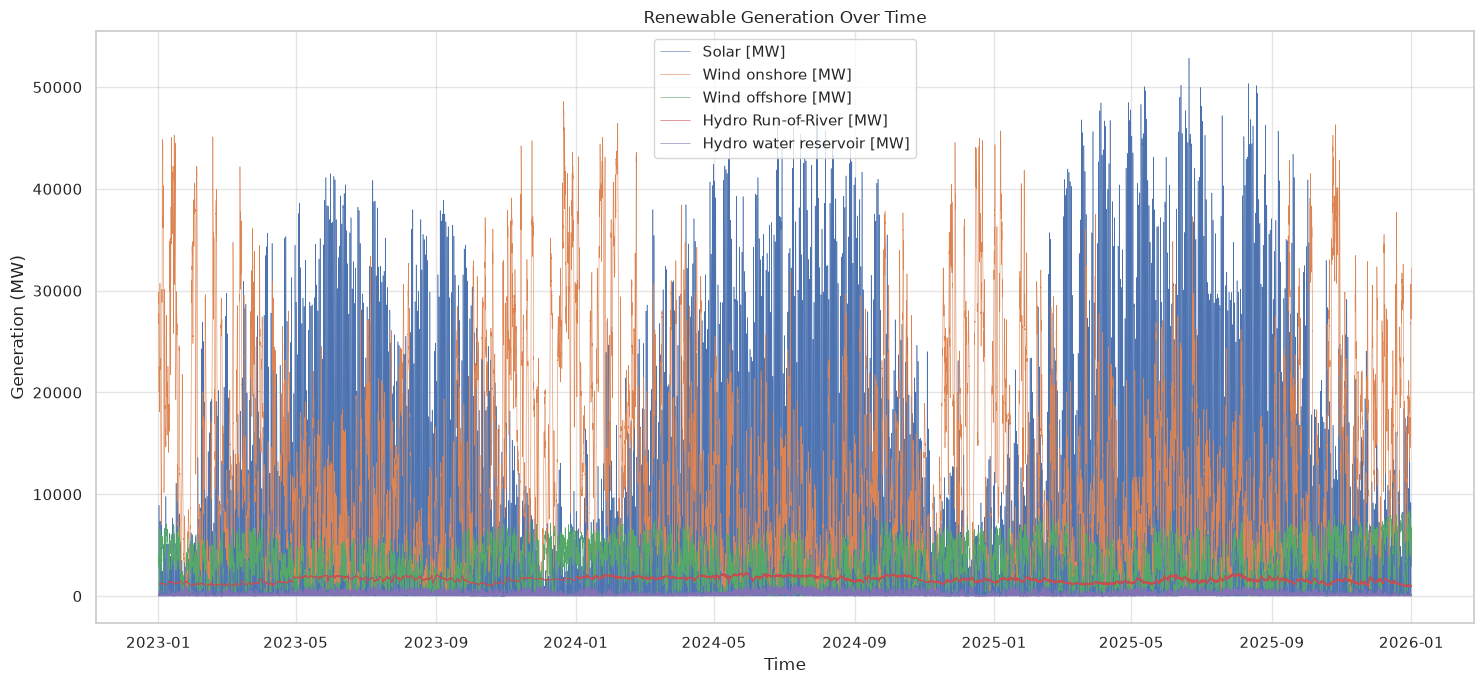

In [25]:
plt.figure(figsize=(15, 7))

for column in renewable_columns:
    plt.plot(
        df["Timestamp_UTC"],
        df[column],
        linewidth=0.4,
        label=column
    )

plt.title("Renewable Generation Over Time")
plt.xlabel("Time")
plt.ylabel("Generation (MW)")
plt.legend()

plt.tight_layout()
plt.show()

## 11. Renewable Coverage Analysis

Renewable coverage represents the proportion of electricity demand that is simultaneously represented by renewable generation.

It is calculated as:

\[
Renewable\ Coverage_t =
\frac{Renewable\ Generation_t}{Load_t}\times100
\]

The dataset contains the derived variable `renewable_coverage_pct`, which will be independently validated later in the notebook.

In [26]:
coverage_statistics = df["renewable_coverage_pct"].describe(
    percentiles=[
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

coverage_statistics

count   105216.00
mean        47.00
std         24.89
min          3.01
1%           7.62
5%          11.85
10%         15.60
25%         26.48
50%         44.55
75%         64.71
90%         82.59
95%         92.18
99%        105.23
max        125.75
Name: renewable_coverage_pct, dtype: float64

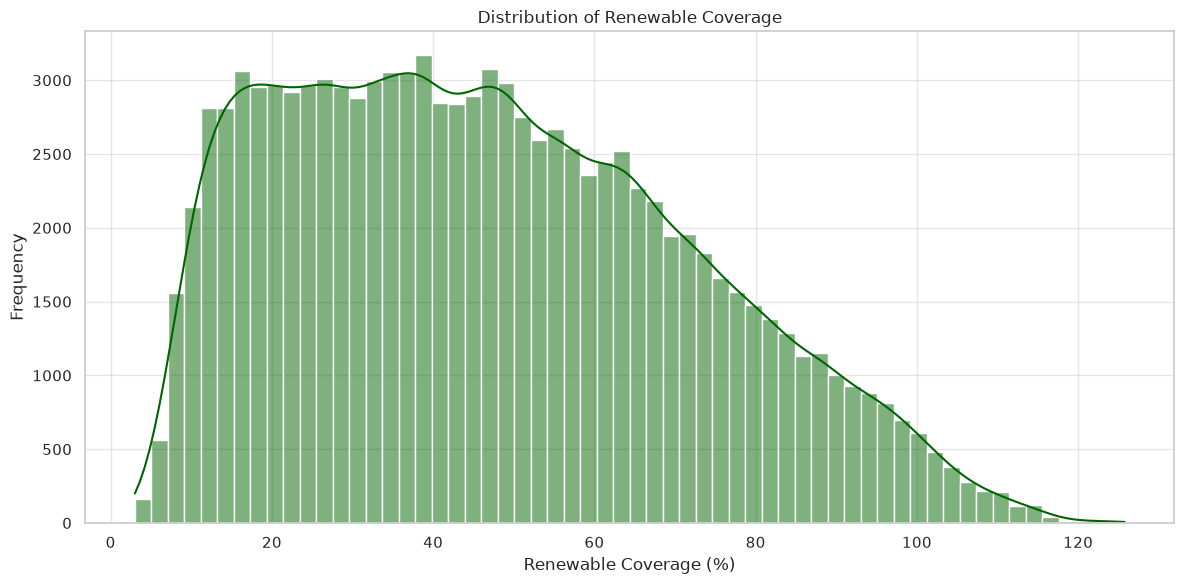

In [27]:
plt.figure(figsize=(12, 6))

sns.histplot(
    df["renewable_coverage_pct"],
    bins=60,
    kde=True,
    color="darkgreen"
)

plt.title("Distribution of Renewable Coverage")
plt.xlabel("Renewable Coverage (%)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 12. Renewable-Demand Gap Analysis

The renewable-demand gap is defined as:

\[
G_t = Load_t - Renewable\ Generation_t
\]

A positive gap indicates that electricity demand exceeds simultaneous renewable generation. A negative gap indicates that renewable generation exceeds the observed electricity demand.

In [28]:
gap_statistics = df["renewable_gap_MW"].describe(
    percentiles=[
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

gap_statistics

count   105216.00
mean     28009.22
std      14014.45
min     -10588.80
1%       -2461.00
5%        3910.18
10%       8807.20
25%      18329.62
50%      28446.10
75%      37721.80
90%      45906.25
95%      50862.33
99%      59678.73
max      66112.90
Name: renewable_gap_MW, dtype: float64

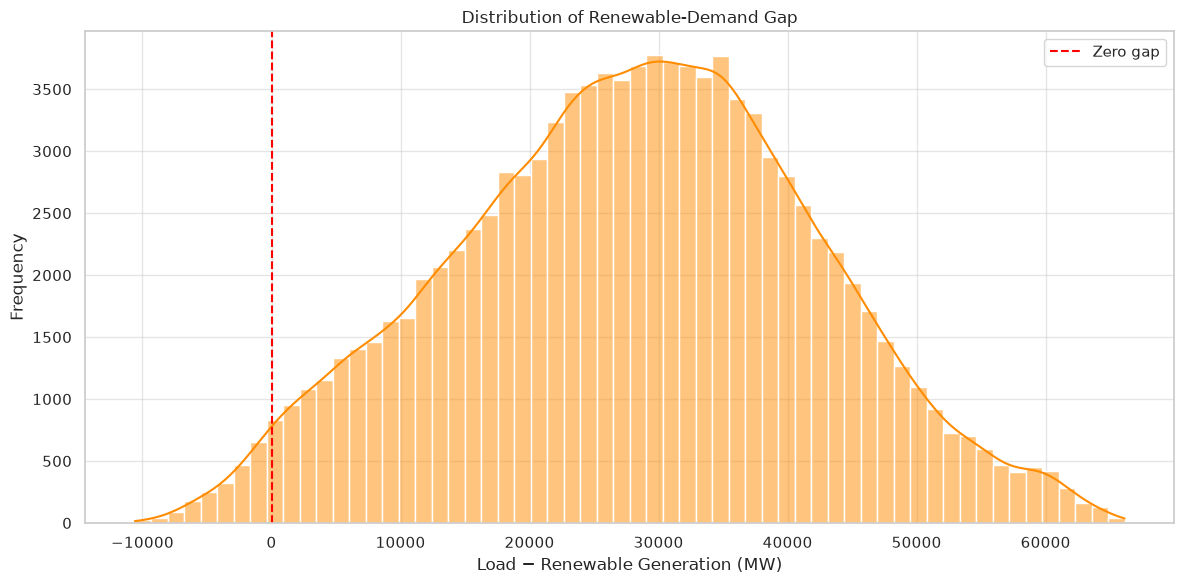

In [29]:
plt.figure(figsize=(12, 6))

sns.histplot(
    df["renewable_gap_MW"],
    bins=60,
    kde=True,
    color="darkorange"
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
    label="Zero gap"
)

plt.title("Distribution of Renewable-Demand Gap")
plt.xlabel("Load − Renewable Generation (MW)")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

## 13. Validation of Derived Variables

The dataset contains several variables derived from the underlying electricity-system measurements.

Before using these variables in the analysis, their numerical consistency is independently checked.

The following relationships are examined:

1. Total renewable generation
2. Renewable-demand gap
3. Renewable coverage


### Validation of Total Renewable Generation

The total renewable generation variable is validated by independently summing the recorded generation from solar, onshore wind, offshore wind, and hydro sources. The independently calculated value is compared with the `renewable_total_MW` variable provided in the dataset to verify its numerical consistency before using it in subsequent renewable-coverage and reliability-window analyses.

In [30]:
calculated_renewable_total = (
    df["Solar [MW]"]
    + df["Wind onshore [MW]"]
    + df["Wind offshore [MW]"]
    + df["Hydro Run-of-River [MW]"]
    + df["Hydro water reservoir [MW]"]
)

renewable_total_error = (
    calculated_renewable_total -
    df["renewable_total_MW"]
).abs()

print(
    "Maximum absolute error in renewable total:",
    renewable_total_error.max().round(15)
)

Maximum absolute error in renewable total: 1.4552e-11


**Validation Result:** The independently calculated total renewable generation agrees with the `renewable_total_MW` variable to within numerical floating-point precision. The maximum absolute difference is approximately \(1.46 \times 10^{-11}\) MW, which is effectively zero. Therefore, the renewable total variable is considered internally consistent and suitable for subsequent analysis.

### Validation of Renewable-Demand Gap

The renewable-demand gap is independently calculated as the difference between electricity load and total renewable generation. The calculated values are compared with the `renewable_gap_MW` variable provided in the dataset to verify its numerical consistency. This validation ensures that the renewable-demand gap used in subsequent peak-load and reliability-window analyses accurately represents the difference between electricity demand and available renewable generation.

In [31]:
calculated_gap = (
    df["Load [MW]"] -
    df["renewable_total_MW"]
)

gap_error = (
    calculated_gap -
    df["renewable_gap_MW"]
).abs()

print(
    "Maximum absolute error in renewable-demand gap:",
    gap_error.max().round(15)
)

Maximum absolute error in renewable-demand gap: 1.4552e-11


### Validation of Renewable Coverage

Renewable coverage is independently calculated as the proportion of total renewable generation relative to electricity demand. The calculated values are compared with the `renewable_coverage_pct` variable provided in the dataset to verify its numerical consistency. This validation ensures that the renewable coverage measure accurately represents the contribution of available renewable generation to electricity demand and can be reliably used in subsequent renewable reliability-window analysis.

In [32]:
calculated_coverage = (
    df["renewable_total_MW"] /
    df["Load [MW]"] *
    100
)

coverage_error = (
    calculated_coverage -
    df["renewable_coverage_pct"]
).abs()

print(
    "Maximum absolute error in renewable coverage:",
    coverage_error.max().round(12)
)

Maximum absolute error in renewable coverage: 4.9992e-08


## 14. Peak-Load Analysis

Peak-load conditions are important because the project focuses on identifying periods in which high electricity demand may coincide with limited renewable availability.

The dataset contains a `peak_flag` variable. Its relationship with the observed load distribution is examined before it is used in subsequent analysis.

In [33]:
print("Peak flag distribution:")
print(df["peak_flag"].value_counts())

print("\nPeak flag percentage:")
print(
    df["peak_flag"]
    .value_counts(normalize=True)
    .mul(100)
)

Peak flag distribution:
peak_flag
0    94695
1    10521
Name: count, dtype: int64

Peak flag percentage:
peak_flag
0   90.00
1   10.00
Name: proportion, dtype: float64


In [34]:
peak_threshold = df["Load [MW]"].quantile(0.90)

print(
    f"90th percentile load threshold: {peak_threshold:,.2f} MW"
)

print(
    f"Minimum load among peak observations: "
    f"{df.loc[df['peak_flag'] == 1, 'Load [MW]'].min():,.2f} MW"
)

print(
    f"Maximum load among non-peak observations: "
    f"{df.loc[df['peak_flag'] == 0, 'Load [MW]'].max():,.2f} MW"
)

90th percentile load threshold: 65,389.20 MW
Minimum load among peak observations: 65,389.30 MW
Maximum load among non-peak observations: 65,389.20 MW


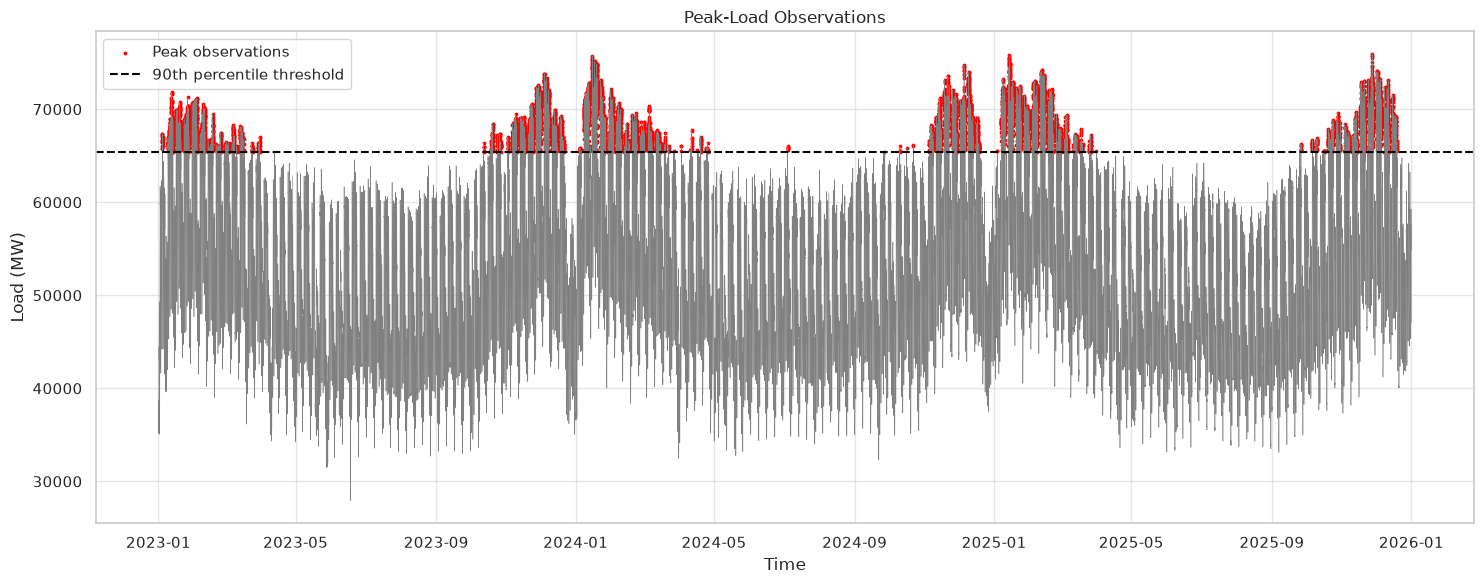

In [35]:
plt.figure(figsize=(15, 6))

plt.plot(
    df["Timestamp_UTC"],
    df["Load [MW]"],
    linewidth=0.4,
    color="gray"
)

peak_observations = df[df["peak_flag"] == 1]

plt.scatter(
    peak_observations["Timestamp_UTC"],
    peak_observations["Load [MW]"],
    s=3,
    color="red",
    label="Peak observations"
)

plt.axhline(
    peak_threshold,
    color="black",
    linestyle="--",
    label="90th percentile threshold"
)

plt.title("Peak-Load Observations")
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.legend()

plt.tight_layout()
plt.show()

## 15. Peak Demand and Renewable Availability

The central research question is whether periods of high electricity demand coincide with relatively low renewable availability.

Peak and non-peak observations are therefore compared using:

- Electricity load
- Total renewable generation
- Renewable coverage
- Renewable-demand gap

In [36]:
peak_comparison = (
    df.groupby("peak_flag")[
        [
            "Load [MW]",
            "renewable_total_MW",
            "renewable_coverage_pct",
            "renewable_gap_MW"
        ]
    ]
    .mean()
)

peak_comparison.T

peak_flag,0,1
Load [MW],51091.31,68502.71
renewable_total_MW,24567.69,27122.28
renewable_coverage_pct,47.82,39.64
renewable_gap_MW,26523.63,41380.43


In [37]:
peak_comparison_percentage = (
    df.groupby("peak_flag")[
        ["renewable_coverage_pct"]
    ]
    .mean()
)

peak_comparison_percentage.T

peak_flag,0,1
renewable_coverage_pct,47.82,39.64


### Renewable Coverage During Peak and Non-Peak Periods

This analysis compares renewable coverage during peak-demand and non-peak-demand periods. The comparison helps determine whether periods of high electricity demand are associated with relatively lower renewable availability. This relationship is important for identifying potential renewable-demand mismatch conditions and candidate reliability windows.

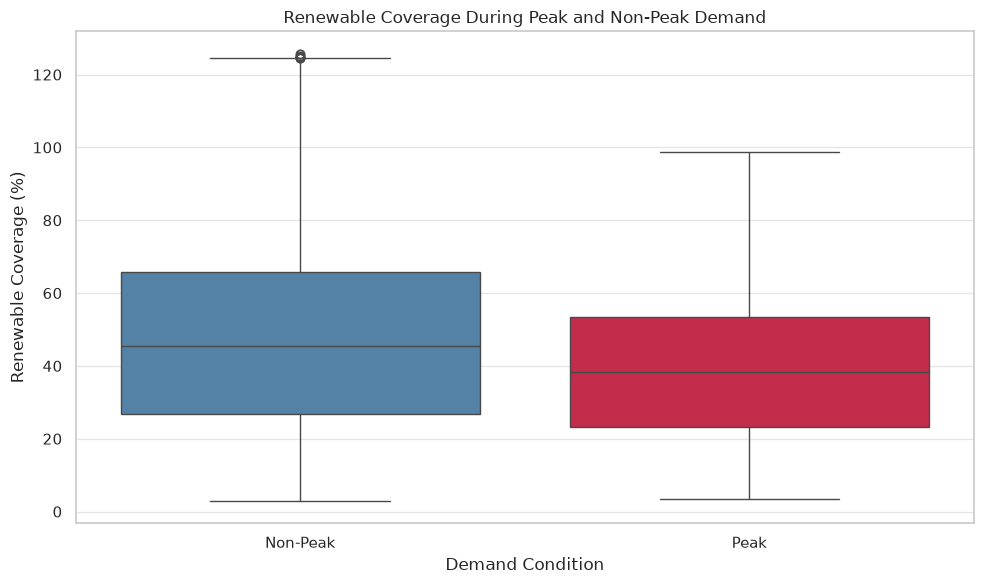

In [38]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="peak_flag",
    y="renewable_coverage_pct",
    hue="peak_flag",
    palette=["steelblue", "crimson"],
    legend=False
)

plt.xticks(
    [0, 1],
    ["Non-Peak", "Peak"]
)

plt.title("Renewable Coverage During Peak and Non-Peak Demand")
plt.xlabel("Demand Condition")
plt.ylabel("Renewable Coverage (%)")

plt.tight_layout()
plt.show()

## 16. Renewable Reliability Window Analysis

A candidate renewable reliability window is defined for exploratory analysis as an observation satisfying both:

1. Electricity demand is within the high-demand region.
2. Renewable coverage is within the low-renewable region.

The thresholds are derived from the observed distributions rather than arbitrarily selected.

In [39]:
high_demand_threshold = df["Load [MW]"].quantile(0.90)

low_renewable_threshold = (
    df["renewable_coverage_pct"].quantile(0.25)
)

print(
    f"High-demand threshold: "
    f"{high_demand_threshold:,.2f} MW"
)

print(
    f"Low-renewable threshold: "
    f"{low_renewable_threshold:.2f}%"
)

High-demand threshold: 65,389.20 MW
Low-renewable threshold: 26.48%


In [40]:
reliability_candidates = df[
    (df["Load [MW]"] >= high_demand_threshold) &
    (df["renewable_coverage_pct"] <= low_renewable_threshold)
].copy()

print(
    "Potential reliability-window observations:",
    len(reliability_candidates)
)

print(
    f"Percentage of dataset: "
    f"{len(reliability_candidates) / len(df) * 100:.2f}%"
)

Potential reliability-window observations: 3132
Percentage of dataset: 2.98%


### Reliability Windows by Hour

This analysis examines the distribution of potential renewable reliability-window observations across the 24-hour daily cycle. By identifying the hours in which high electricity demand coincides with low renewable coverage, the analysis helps determine recurring periods of increased renewable-demand mismatch and potential grid stress.

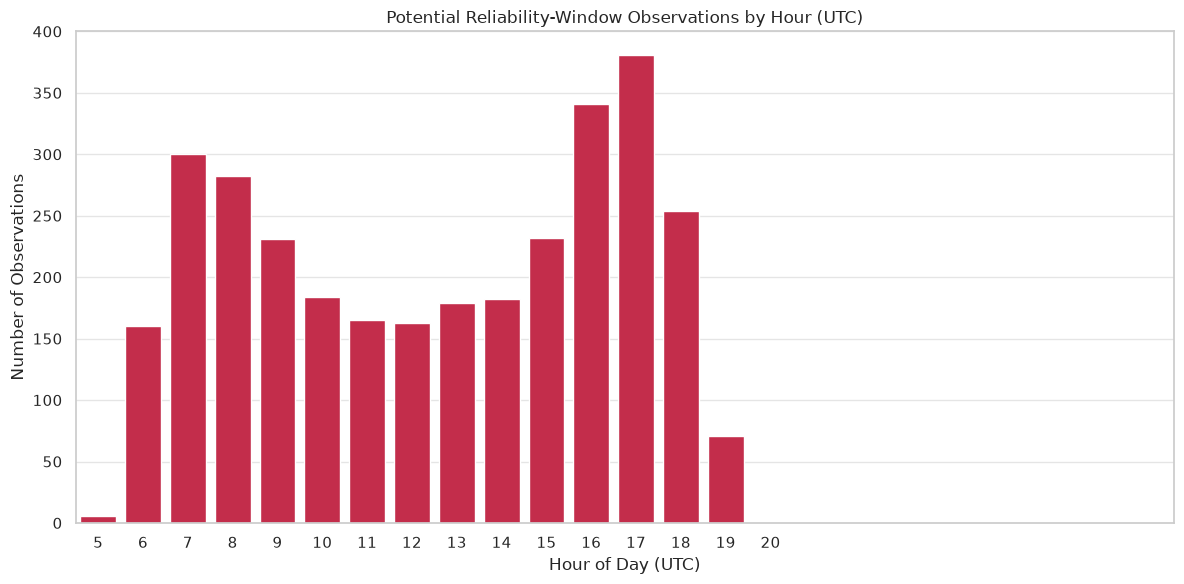

In [41]:
reliability_by_hour = (
    reliability_candidates
    .groupby("hour")
    .size()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=reliability_by_hour.index,
    y=reliability_by_hour.values,
    color="crimson"
)

plt.title(
    "Potential Reliability-Window Observations by Hour (UTC)"
)

plt.xlabel("Hour of Day (UTC)")
plt.ylabel("Number of Observations")

plt.xticks(range(25))

plt.tight_layout()
plt.show()

### Reliability Windows by Month

This analysis examines the monthly distribution of potential renewable reliability-window observations. Identifying the months in which high electricity demand coincides with low renewable coverage helps reveal seasonal patterns in renewable-demand mismatch and provides insight into periods that may require increased grid flexibility, storage support, or operational preparedness.

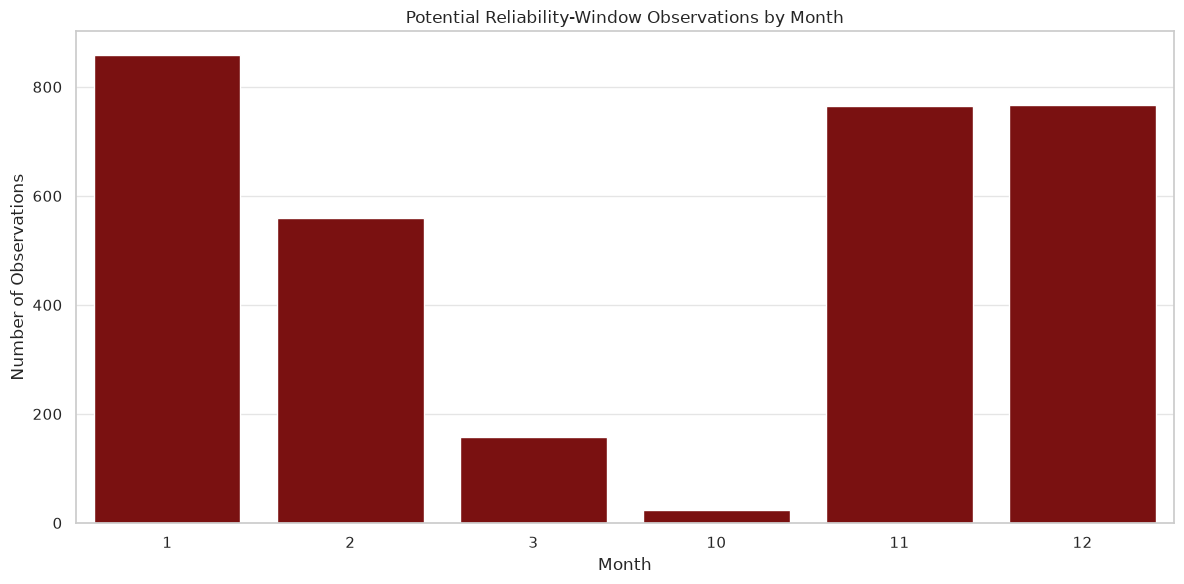

In [42]:
reliability_by_month = (
    reliability_candidates
    .groupby("month")
    .size()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=reliability_by_month.index,
    y=reliability_by_month.values,
    color="darkred"
)

plt.title(
    "Potential Reliability-Window Observations by Month"
)

plt.xlabel("Month")
plt.ylabel("Number of Observations")

plt.tight_layout()
plt.show()

### Reliability-Window Heatmap

The heatmap visualizes the frequency of potential renewable reliability-window observations across different months and hours of the day. It provides a combined temporal view of periods where high electricity demand coincides with low renewable coverage. Darker regions indicate a higher concentration of such observations, helping identify recurring seasonal and daily patterns that may represent periods of increased grid stress and potential requirements for storage, flexible generation, or demand-side management.

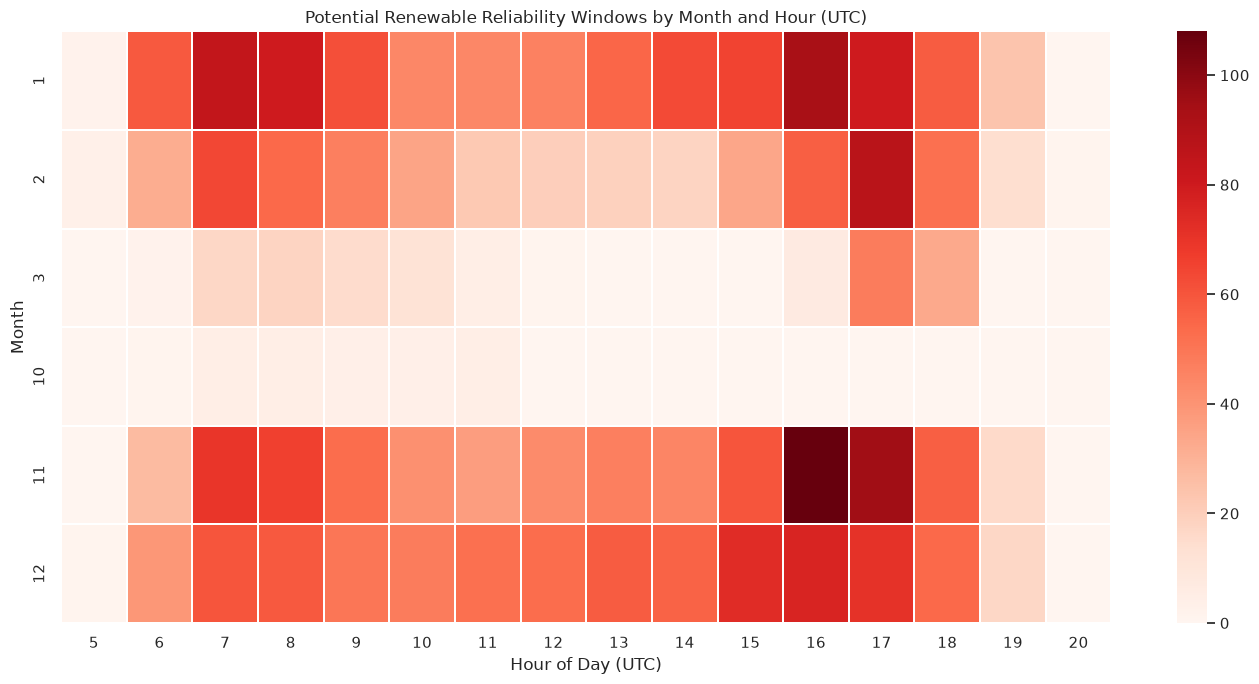

In [43]:
reliability_heatmap = (
    reliability_candidates
    .groupby(["month", "hour"])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(14, 7))

sns.heatmap(
    reliability_heatmap,
    cmap="Reds",
    linewidths=0.2
)

plt.title(
    "Potential Renewable Reliability Windows by Month and Hour (UTC)"
)

plt.xlabel("Hour of Day (UTC)")
plt.ylabel("Month")

plt.tight_layout()
plt.show()

## 17. Correlation Analysis

Correlation analysis is used to examine linear relationships between electricity demand and renewable-generation variables.

Correlation does not imply causation. The results are therefore used for exploratory feature understanding rather than causal interpretation.

In [44]:
correlation_columns = [
    "Load [MW]",
    "Solar [MW]",
    "Wind onshore [MW]",
    "Wind offshore [MW]",
    "Hydro Run-of-River [MW]",
    "Hydro water reservoir [MW]",
    "renewable_total_MW",
    "renewable_coverage_pct",
    "renewable_gap_MW"
]

correlation_matrix = (
    df[correlation_columns]
    .corr()
)

correlation_matrix.T

,Load [MW],Solar [MW],Wind onshore [MW],Wind offshore [MW],Hydro Run-of-River [MW],Hydro water reservoir [MW],renewable_total_MW,renewable_coverage_pct,renewable_gap_MW
Load [MW],1.00,0.19,0.15,0.14,-0.05,0.18,0.29,-0.00,0.37
Solar [MW],0.19,1.00,-0.25,-0.25,0.11,-0.08,0.61,0.58,-0.47
Wind onshore [MW],0.15,-0.25,1.00,0.59,-0.16,-0.30,0.61,0.57,-0.49
Wind offshore [MW],0.14,-0.25,0.59,1.00,-0.13,-0.23,0.36,0.35,-0.26
Hydro Run-of-River [MW],-0.05,0.11,-0.16,-0.13,1.00,0.36,-0.01,-0.01,-0.02
Hydro water reservoir [MW],0.18,-0.08,-0.30,-0.23,0.36,1.00,-0.30,-0.35,0.40
renewable_total_MW,0.29,0.61,0.61,0.36,-0.01,-0.30,1.00,0.94,-0.78
renewable_coverage_pct,-0.00,0.58,0.57,0.35,-0.01,-0.35,0.94,1.00,-0.92
renewable_gap_MW,0.37,-0.47,-0.49,-0.26,-0.02,0.40,-0.78,-0.92,1.00


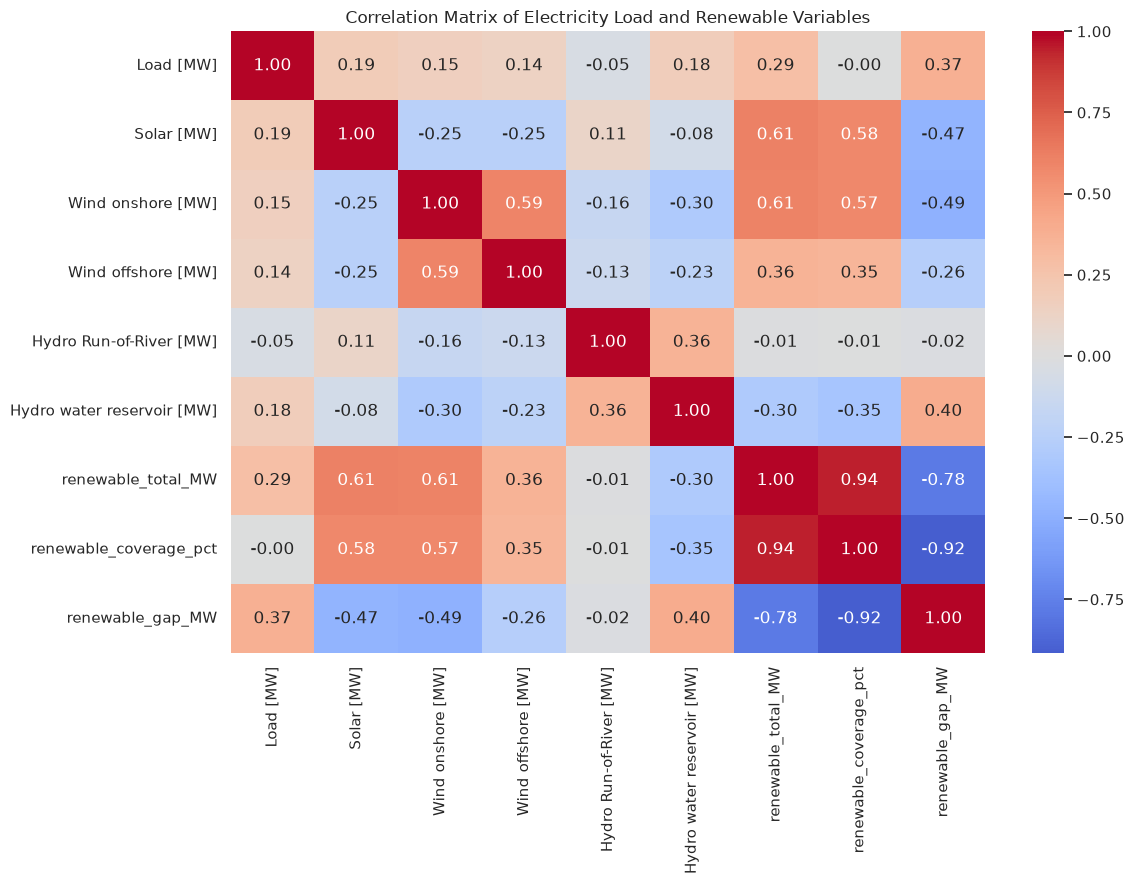

In [45]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix of Electricity Load and Renewable Variables"
)

plt.tight_layout()
plt.show()

## 18. Load and Renewable Generation Relationship

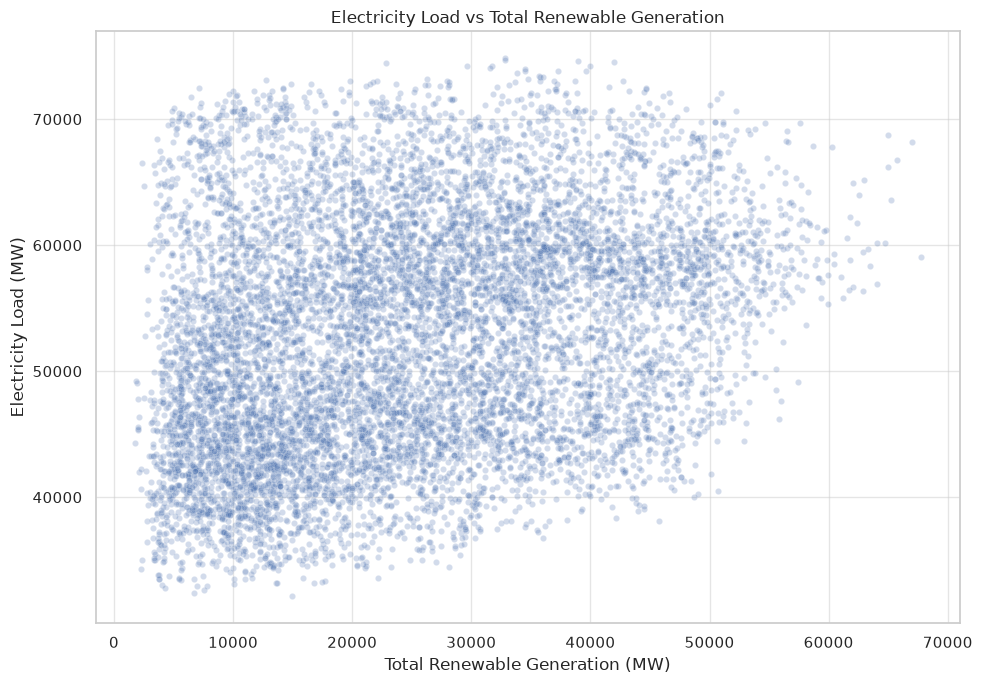

In [46]:

plot_sample = df.sample(
    n=min(10000, len(df)),
    random_state=42
)


plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=plot_sample,
    x="renewable_total_MW",
    y="Load [MW]",
    alpha=0.25,
    s=20
)


plt.title("Electricity Load vs Total Renewable Generation")
plt.xlabel("Total Renewable Generation (MW)")
plt.ylabel("Electricity Load (MW)")

plt.tight_layout()
plt.show()

## 19. Risk Score Exploration

The dataset contains a precomputed `risk_score`.

This variable is examined descriptively, but it is not automatically used as a machine-learning predictor because its construction may depend on other variables involved in the prediction problem.

Its definition should therefore be verified before it is used as an independent predictive feature.

In [47]:
risk_statistics = df["risk_score"].describe(
    percentiles=[
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

risk_statistics

count   105216.00
mean         0.06
std          0.19
min          0.00
50%          0.00
75%          0.00
90%          0.00
95%          0.62
99%          0.87
max          0.96
Name: risk_score, dtype: float64

In [48]:
non_zero_risk = (
    df["risk_score"] > 0
).sum()

print(
    "Observations with non-zero risk score:",
    non_zero_risk
)

print(
    f"Percentage of observations: "
    f"{non_zero_risk / len(df) * 100:.2f}%"
)

Observations with non-zero risk score: 10521
Percentage of observations: 10.00%


## 20. Key Exploratory Findings

The exploratory analysis provides the following data-driven observations:

1. The dataset contains 105,216 observations and 17 variables covering approximately three years at 15-minute temporal resolution.

2. Timestamp validation confirms continuous 15-minute observations across the study period.

3. No missing values, duplicate rows, or duplicate timestamps were identified.

4. Electricity demand ranges from approximately 27,932.9 MW to 75,965.7 MW, with a mean of approximately 52,832.4 MW.

5. The 90th percentile of electricity demand is approximately 65,389.2 MW. The existing peak flag identifies approximately 10% of observations and corresponds to this upper demand region.

6. Mean renewable coverage is approximately 47.0%, with substantial variation across observations.

7. The renewable-demand gap also exhibits substantial variation, including periods where renewable generation exceeds simultaneous demand.

8. The derived renewable-total, renewable-coverage, and renewable-gap variables are numerically consistent with their underlying variables.

9. Peak-demand observations can therefore be compared with renewable availability to investigate whether demand spikes coincide with low renewable coverage.

10. The combination of high demand and low renewable coverage provides a data-driven basis for identifying candidate renewable reliability windows.


## 21. EDA Conclusion

The exploratory analysis establishes the temporal, statistical, and energy-generation characteristics of the ENTSO-E dataset. The dataset provides continuous high-resolution observations of electricity demand and multiple renewable-generation sources over approximately three years.

The analysis demonstrates substantial variability in electricity demand and renewable availability. More importantly, the results provide a basis for jointly examining demand spikes and renewable coverage rather than analyzing electricity demand and renewable generation independently.

The identified high-demand and low-renewable conditions provide the basis for defining renewable reliability windows. Temporal characteristics and validated load and renewable variables will inform the feature-selection process for peak-load prediction.

For machine-learning experiments, variables derived directly from the future target load will be excluded where their use would introduce target leakage.


## 22. Save Cleaned Dataset

In [49]:
cleaned_directory = Path("../data/Cleaned")

cleaned_directory.mkdir(
    parents=True,
    exist_ok=True
)

cleaned_path = cleaned_directory / "CleanDataset.csv"

df.to_csv(
    cleaned_path,
    index=False
)

print("Cleaned dataset saved to:")
print(cleaned_path)

Cleaned dataset saved to:
../data/Cleaned/CleanDataset.csv


# End of Exploratory Data Analysis

The completed EDA provides the empirical basis for the next stages of the project:

1. Reliability-window methodology
2. Feature selection
3. Peak-load prediction
4. Model evaluation
5. Grid-risk assessment

## 23. Export Key EDA Results

The main statistical results generated during the exploratory analysis are consolidated and exported for use in the final report and subsequent analysis.

In [50]:
# Create a summary of important EDA metrics

eda_summary = pd.DataFrame({
    "Metric": [
        "Number of observations",
        "Number of variables",
        "Study period start",
        "Study period end",
        "Average load (MW)",
        "Maximum load (MW)",
        "90th percentile load (MW)",
        "Average renewable coverage (%)",
        "Minimum renewable coverage (%)",
        "Maximum renewable coverage (%)",
        "Average renewable-demand gap (MW)",
        "Number of peak observations",
        "Number of reliability-window observations"
    ],
    "Value": [
        len(df),
        len(df.columns),
        df["Timestamp_UTC"].min(),
        df["Timestamp_UTC"].max(),
        df["Load [MW]"].mean(),
        df["Load [MW]"].max(),
        df["Load [MW]"].quantile(0.90),
        df["renewable_coverage_pct"].mean(),
        df["renewable_coverage_pct"].min(),
        df["renewable_coverage_pct"].max(),
        df["renewable_gap_MW"].mean(),
        (df["peak_flag"] == 1).sum(),
        len(reliability_candidates)
    ]
})

display(eda_summary)

,Metric,Value
0,Number of observations,105216
1,Number of variables,17
2,Study period start,2022-12-31 23:00:00+00:00
3,Study period end,2025-12-31 22:45:00+00:00
4,Average load (MW),52832.35
5,Maximum load (MW),75965.70
6,90th percentile load (MW),65389.20
7,Average renewable coverage (%),47.00
8,Minimum renewable coverage (%),3.01
9,Maximum renewable coverage (%),125.75


## 24. Save EDA Summary

The consolidated EDA summary is saved as a CSV file so that the principal findings can be referenced during report preparation without manually copying values from the notebook.

In [51]:
summary_path = Path("../data/Cleaned/EDA_Summary.csv")

eda_summary.to_csv(
    summary_path,
    index=False
)

print(f"EDA summary saved to: {summary_path}")

EDA summary saved to: ../data/Cleaned/EDA_Summary.csv


## 25. Final EDA Summary

The exploratory analysis establishes the statistical and temporal characteristics of the ENTSO-E electricity-system dataset. It examines electricity demand, renewable-generation variability, renewable coverage, renewable-demand gaps, peak-load conditions, and candidate renewable reliability windows.

The results provide the empirical foundation for the next stage of the project, which focuses on feature engineering, peak-load prediction, and reliability-window assessment.
